In [1]:
from youtube_comment_downloader import YoutubeCommentDownloader
import csv

# Ganti dengan ID video YouTube, misalnya 'dQw4w9WgXcQ'
VIDEO_ID = '2iz43OAhWYc'

def download_comments(video_id, max_comments=1000, output_file='comments.csv'):
    downloader = YoutubeCommentDownloader()
    comments = downloader.get_comments_from_url(f'https://www.youtube.com/watch?v={video_id}', sort_by=0)

    count = 0
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Author', 'Comment', 'Time'])

        for comment in comments:
            writer.writerow([comment['author'], comment['text'], comment['time']])
            count += 1
            if count >= max_comments:
                break

    print(f"Berhasil mengunduh {count} komentar dan menyimpannya ke '{output_file}'.")

if __name__ == '__main__':
    download_comments(VIDEO_ID)


Berhasil mengunduh 1000 komentar dan menyimpannya ke 'comments.csv'.


In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# === Load Data ===
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

X_train = train_df['Cleaned_Comment']
y_train = train_df['Sentiment_Label']

X_test = test_df['Cleaned_Comment']
y_test = test_df['Sentiment_Label']

# === TF-IDF Vectorization ===
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# === Naive Bayes ===
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_pred = nb_model.predict(X_test_vec)

print("\n=== Naive Bayes ===")
print("Akurasi:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

# === Support Vector Machine ===
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_vec, y_train)
svm_pred = svm_model.predict(X_test_vec)

print("\n=== Support Vector Machine ===")
print("Akurasi:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))



=== Naive Bayes ===
Akurasi: 0.6633165829145728
              precision    recall  f1-score   support

     negatif       0.90      0.37      0.52        52
      netral       0.59      0.78      0.67        83
     positif       0.71      0.75      0.73        64

    accuracy                           0.66       199
   macro avg       0.73      0.63      0.64       199
weighted avg       0.71      0.66      0.65       199


=== Support Vector Machine ===
Akurasi: 0.7185929648241206
              precision    recall  f1-score   support

     negatif       0.72      0.54      0.62        52
      netral       0.64      0.76      0.70        83
     positif       0.84      0.81      0.83        64

    accuracy                           0.72       199
   macro avg       0.73      0.70      0.71       199
weighted avg       0.73      0.72      0.72       199



In [14]:
import re
import pandas as pd
import emoji

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# === STEP 1: Load data ===
df = pd.read_csv('comments.csv')  # pastikan ada kolom 'Comment'

# === STEP 2: Inisialisasi stopwords dan stemmer ===
stopword_factory = StopWordRemoverFactory()
stemmer_factory = StemmerFactory()

stopwords = set(stopword_factory.get_stop_words())
stemmer = stemmer_factory.create_stemmer()

# Tambahan stopwords bahasa sehari-hari
additional_stopwords = {
    'yg', 'gak', 'ga', 'udah', 'dah', 'aja', 'banget', 'bgt', 'emang', 'gimana', 
    'kayak', 'kaya', 'lagi', 'lg', 'nih', 'sih', 'dong', 'deh', 'tau', 'tahu',
    'juga', 'jg', 'sama', 'sm', 'terus', 'trs', 'abis', 'habis', 'mau', 'bisa',
    'gitu', 'gt', 'kalo', 'kalau', 'pake', 'pakai', 'udahan', 'udh', 'gini',
    'begini', 'begitu', 'masa', 'malah', 'jadi', 'jd', 'cuma', 'cm',
    'pasti', 'bakal', 'nanti', 'sekarang', 'skrg', 'wkwk', 'haha', 'hehe',
    'wow', 'wah', 'oke', 'ok', 'thanks', 'thx', 'mantap', 'keren', 'bagus'
}
stopwords.update(additional_stopwords)

# === STEP 3: Fungsi Pembersihan ===
def clean_text(text):
    if pd.isna(text):
        return ''
    
    text = str(text)

    # Hilangkan emoji
    text = emoji.replace_emoji(text, replace='')

    # Hilangkan URL, mention, hashtag
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Hilangkan angka dan simbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Lowercase
    text = text.lower()

    # Hilangkan stopwords
    words = [word for word in text.split() if word not in stopwords]
    text = ' '.join(words)

    # Stemming
    text = stemmer.stem(text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# === STEP 4: Terapkan Preprocessing ===
print("🔄 Membersihkan komentar...")
df['Cleaned_Comment'] = df['Comment'].astype(str).apply(clean_text)

# === STEP 5: Simpan ke file baru ===
output_path = 'preprocessing.csv'
df.to_csv(output_path, index=False)
print(f"✅ Preprocessing selesai. File disimpan ke: {output_path}")

# === STEP 6: Tampilkan sampel hasil ===
print("\n📌 Contoh hasil preprocessing:")
print(df[['Comment', 'Cleaned_Comment']].head())


🔄 Membersihkan komentar...
✅ Preprocessing selesai. File disimpan ke: preprocessing.csv

📌 Contoh hasil preprocessing:
                                             Comment  \
0  Kebohongan sulit susah berbelit belit dan keju...   
1  Menutupi kebohongan\nItu sangat sulit. Harus d...   
2   Luar biasa.Pak Khozinudin..\nSehat selalu Pak...   
3  Indonesia tidak kekurangan ahli tetap kekurang...   
4  Seribu ahli tak kan mampu menutupi kebohongan....   

                                     Cleaned_Comment  
0  bohong sulit susah belit belit jujur sangat se...  
1  tutup bohong sangat sulit tutup dgn bohong lam...  
2          luar biasapak khozinudin sehat selalu pak  
3     indonesia kurang ahli tetap kurang orang jujur  
4  ribu ahli tak kan mampu tutup kebohongansatu j...  
✅ Preprocessing selesai. File disimpan ke: preprocessing.csv

📌 Contoh hasil preprocessing:
                                             Comment  \
0  Kebohongan sulit susah berbelit belit dan keju...   
1  Menutup

In [15]:
# Baca kamus sentimen INSET
def load_sentiment_dictionary(file_path):
    """Membaca file kamus sentimen dan mengembalikan set kata-kata"""
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            words = set(word.strip().lower() for word in file.readlines() if word.strip())
        return words
    except FileNotFoundError:
        print(f"File {file_path} tidak ditemukan!")
        return set()

# Load kamus positif dan negatif
positive_words = load_sentiment_dictionary('positive.txt')
negative_words = load_sentiment_dictionary('negative.txt')

print(f"Kata positif dimuat: {len(positive_words)} kata")
print(f"Kata negatif dimuat: {len(negative_words)} kata")

def calculate_sentiment_score(text):
    """Menghitung skor sentimen berdasarkan kata positif dan negatif"""
    if pd.isna(text) or text == '':
        return 0
    
    words = text.split()
    positive_score = sum(1 for word in words if word in positive_words)
    negative_score = sum(1 for word in words if word in negative_words)
    
    return positive_score - negative_score

def classify_sentiment(score):
    """Klasifikasi sentimen berdasarkan skor"""
    if score > 0:
        return 'positif'
    elif score < 0:
        return 'negatif'
    else:
        return 'netral'

# Baca data hasil preprocessing
df_cleaned = pd.read_csv('preprocessing.csv')

# Hitung skor sentimen untuk setiap komentar
df_cleaned['Sentiment_Score'] = df_cleaned['Cleaned_Comment'].apply(calculate_sentiment_score)

# Klasifikasi sentimen
df_cleaned['Sentiment_Label'] = df_cleaned['Sentiment_Score'].apply(classify_sentiment)

# Simpan hasil labeling
df_cleaned.to_csv('labelling.csv', index=False)

# Tampilkan statistik hasil labeling
print("\n=== Statistik Hasil Labeling ===")
sentiment_counts = df_cleaned['Sentiment_Label'].value_counts()
print(sentiment_counts)
print(f"\nPersentase:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / len(df_cleaned)) * 100
    print(f"{sentiment}: {count} ({percentage:.1f}%)")

# Tampilkan beberapa contoh hasil
print("\n=== Contoh Hasil Labeling ===")
print(df_cleaned[['Comment', 'Cleaned_Comment', 'Sentiment_Score', 'Sentiment_Label']].head(10))

Kata positif dimuat: 1178 kata
Kata negatif dimuat: 2389 kata

=== Statistik Hasil Labeling ===
Sentiment_Label
netral     422
positif    320
negatif    258
Name: count, dtype: int64

Persentase:
netral: 422 (42.2%)
positif: 320 (32.0%)
negatif: 258 (25.8%)

=== Contoh Hasil Labeling ===
                                             Comment  \
0  Kebohongan sulit susah berbelit belit dan keju...   
1  Menutupi kebohongan\nItu sangat sulit. Harus d...   
2   Luar biasa.Pak Khozinudin..\nSehat selalu Pak...   
3  Indonesia tidak kekurangan ahli tetap kekurang...   
4  Seribu ahli tak kan mampu menutupi kebohongan....   
5  Semoga bisa adil dan tdk berat sebelah. \nJgn ...   
6  Ahmad khozinuddin mantab....\nJelas lugas g ad...   
7  Ahmad betul2 cerdas dan berani menegakkan keju...   
8  pak ahmad pengacara yg sangat cerdas, apa yg d...   
9  Ahmad konudin maju terus membelah ke benaran  ...   

                                     Cleaned_Comment  Sentiment_Score  \
0  bohong sulit susah

In [24]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm

# Baca file komentar
df = pd.read_csv("preprocessing.csv")

# Normalisasi nama kolom (buat cegah KeyError)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Cek apakah kolom 'cleaned_comment' ada
if 'cleaned_comment' not in df.columns:
    raise ValueError("Kolom 'cleaned_comment' tidak ditemukan. Cek nama kolom CSV lo.")

# Ambil list komentar
docs = df['cleaned_comment'].dropna().tolist()

# Inisialisasi model BERTopic (pakai bahasa Indonesia)
topic_model = BERTopic(language="indonesian", verbose=True)

# Fit model ke data
topics, probs = topic_model.fit_transform(docs)

# Lihat topik yang terbentuk
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))  # Top 10 topik




2025-07-01 15:29:39,628 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 31/31 [00:05<00:00,  5.97it/s]
2025-07-01 15:29:49,167 - BERTopic - Embedding - Completed ✓
2025-07-01 15:29:49,168 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-01 15:29:51,212 - BERTopic - Dimensionality - Completed ✓
2025-07-01 15:29:51,213 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-01 15:29:51,237 - BERTopic - Cluster - Completed ✓
2025-07-01 15:29:51,241 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-01 15:29:51,267 - BERTopic - Representation - Completed ✓


   Topic  Count                         Name  \
0     -1    356     -1_adil_jokowi_pak_pihak   
1      0     92   0_bohong_palsu_tutup_bukti   
2      1     71   1_ijazah_asli_palsu_jokowi   
3      2     71  2_ternak_buzzer_nya_mulyono   
4      3     46      3_kamu_panci_bpjs_gerah   
5      4     44  4_allah_benar_lindung_tuhan   
6      5     37       5_amin_hiya_hina_bravo   
7      6     36    6_benci_panik_orang_sulit   
8      7     23      7_polisi_photo_uji_ahli   
9      8     21    8_tuju_pki_modaaar_pahmad   

                                      Representation  \
0  [adil, jokowi, pak, pihak, ahli, hukum, benar,...   
1  [bohong, palsu, tutup, bukti, benar, jujur, ij...   
2  [ijazah, asli, palsu, jokowi, tunjuk, pasal, p...   
3  [ternak, buzzer, nya, mulyono, bui, listio, ke...   
4  [kamu, panci, bpjs, gerah, suryo, tv, baru, du...   
5  [allah, benar, lindung, tuhan, azab, orang, sw...   
6  [amin, hiya, hina, bravo, aku, org, dgn, perca...   
7  [benci, panik, orang

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Baca data hasil labeling
df_labeled = pd.read_csv('labelling.csv')

# Hapus baris dengan cleaned comment kosong atau NaN
df_labeled = df_labeled.dropna(subset=['Cleaned_Comment'])
df_labeled = df_labeled[df_labeled['Cleaned_Comment'].str.strip() != '']

print(f"Total data setelah cleaning: {len(df_labeled)}")
print(f"Distribusi label:")
print(df_labeled['Sentiment_Label'].value_counts())

# Siapkan data untuk splitting
X = df_labeled['Cleaned_Comment']  # Feature (teks yang sudah dibersihkan)
y = df_labeled['Sentiment_Label']  # Target (label sentimen)

# Split data menjadi 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Memastikan proporsi label seimbang di train dan test
)

print(f"\n=== Hasil Split Data ===")
print(f"Data training: {len(X_train)} ({len(X_train)/len(df_labeled)*100:.1f}%)")
print(f"Data testing: {len(X_test)} ({len(X_test)/len(df_labeled)*100:.1f}%)")

print(f"\n=== Distribusi Label di Data Training ===")
print(y_train.value_counts())
print(f"\n=== Distribusi Label di Data Testing ===")
print(y_test.value_counts())

# Simpan data training dan testing ke file CSV
train_data = pd.DataFrame({
    'Cleaned_Comment': X_train,
    'Sentiment_Label': y_train
})

test_data = pd.DataFrame({
    'Cleaned_Comment': X_test,
    'Sentiment_Label': y_test
})

train_data.to_csv('train.csv', index=False)
test_data.to_csv('test.csv', index=False)

print(f"\n=== File Tersimpan ===")
print("Data training disimpan ke: train.csv")
print("Data testing disimpan ke: test.csv")

Total data setelah cleaning: 991
Distribusi label:
Sentiment_Label
netral     413
positif    320
negatif    258
Name: count, dtype: int64

=== Hasil Split Data ===
Data training: 792 (79.9%)
Data testing: 199 (20.1%)

=== Distribusi Label di Data Training ===
Sentiment_Label
netral     330
positif    256
negatif    206
Name: count, dtype: int64

=== Distribusi Label di Data Testing ===
Sentiment_Label
netral     83
positif    64
negatif    52
Name: count, dtype: int64

=== File Tersimpan ===
Data training disimpan ke: train.csv
Data testing disimpan ke: test.csv


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Baca data training dan testing yang sudah di-split
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print(f"=== Data Training dan Testing ===")
print(f"Data training: {len(train_data)} samples")
print(f"Data testing: {len(test_data)} samples")

# Siapkan data teks
X_train_text = train_data['Cleaned_Comment']
X_test_text = test_data['Cleaned_Comment']
y_train = train_data['Sentiment_Label']
y_test = test_data['Sentiment_Label']

# Inisialisasi TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Batasi hingga 5000 fitur teratas
    min_df=2,                 # Kata harus muncul minimal di 2 dokumen
    max_df=0.95,              # Abaikan kata yang muncul di lebih dari 95% dokumen
    stop_words=None,          # Sudah dihapus di preprocessing
    ngram_range=(1, 2),       # Gunakan unigram dan bigram
    lowercase=False           # Sudah lowercase di preprocessing
)

# Fit vectorizer pada data training dan transform data training
print("\n=== Melakukan TF-IDF Vectorization ===")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

# Transform data testing menggunakan vectorizer yang sudah di-fit
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"Shape data training setelah TF-IDF: {X_train_tfidf.shape}")
print(f"Shape data testing setelah TF-IDF: {X_test_tfidf.shape}")
print(f"Jumlah fitur TF-IDF: {len(tfidf_vectorizer.get_feature_names_out())}")

# Tampilkan beberapa fitur teratas berdasarkan rata-rata TF-IDF score
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_scores = np.array(X_train_tfidf.mean(axis=0)).flatten()
top_features_idx = mean_scores.argsort()[-20:][::-1]

print(f"\n=== 20 Fitur Teratas Berdasarkan TF-IDF Score ===")
for i, idx in enumerate(top_features_idx, 1):
    print(f"{i:2d}. {feature_names[idx]}: {mean_scores[idx]:.4f}")

# Tampilkan statistik sparse matrix
print(f"\n=== Statistik Sparse Matrix ===")
print(f"Data training - Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.4f}")
print(f"Data testing - Sparsity: {(1 - X_test_tfidf.nnz / (X_test_tfidf.shape[0] * X_test_tfidf.shape[1])):.4f}")

# Simpan informasi tentang vectorizer untuk debugging
print(f"\n=== Parameter TF-IDF Vectorizer ===")
print(f"Max features: {tfidf_vectorizer.max_features}")
print(f"Min document frequency: {tfidf_vectorizer.min_df}")
print(f"Max document frequency: {tfidf_vectorizer.max_df}")
print(f"N-gram range: {tfidf_vectorizer.ngram_range}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

print(f"\n✅ TF-IDF Vectorization selesai!")
print(f"Data siap untuk training model machine learning.")

=== Data Training dan Testing ===
Data training: 792 samples
Data testing: 199 samples

=== Melakukan TF-IDF Vectorization ===
Shape data training setelah TF-IDF: (792, 1125)
Shape data testing setelah TF-IDF: (199, 1125)
Jumlah fitur TF-IDF: 1125

=== 20 Fitur Teratas Berdasarkan TF-IDF Score ===
 1. ahli: 0.0287
 2. bohong: 0.0261
 3. benar: 0.0241
 4. orang: 0.0209
 5. jokowi: 0.0202
 6. ijazah: 0.0198
 7. jujur: 0.0191
 8. nya: 0.0163
 9. pak: 0.0151
10. asli: 0.0139
11. ahmad: 0.0131
12. tunjuk: 0.0129
13. adil: 0.0121
14. palsu: 0.0119
15. cerdas: 0.0113
16. aamiin: 0.0112
17. percaya: 0.0112
18. acara: 0.0112
19. apa: 0.0109
20. roy: 0.0107

=== Statistik Sparse Matrix ===
Data training - Sparsity: 0.9931
Data testing - Sparsity: 0.9947

=== Parameter TF-IDF Vectorizer ===
Max features: 5000
Min document frequency: 2
Max document frequency: 0.95
N-gram range: (1, 2)
Vocabulary size: 1125

✅ TF-IDF Vectorization selesai!
Data siap untuk training model machine learning.


=== MEMBANGUN MODEL KLASIFIKASI SVM LINEAR ===

🔄 Melatih model SVM Linear...
✅ Training selesai dalam 0.01 detik

🔄 Melakukan prediksi pada data training...
🔄 Melakukan prediksi pada data testing...

EVALUASI MODEL

📊 AKURASI:
Training Accuracy: 0.9886 (98.86%)
Testing Accuracy:  0.7437 (74.37%)

📊 CLASSIFICATION REPORT (Data Testing):
              precision    recall  f1-score   support

     negatif     0.7143    0.6731    0.6931        52
      netral     0.6977    0.7229    0.7101        83
     positif     0.8281    0.8281    0.8281        64

    accuracy                         0.7437       199
   macro avg     0.7467    0.7414    0.7438       199
weighted avg     0.7440    0.7437    0.7436       199


📊 CONFUSION MATRIX:
[[35 16  1]
 [13 60 10]
 [ 1 10 53]]


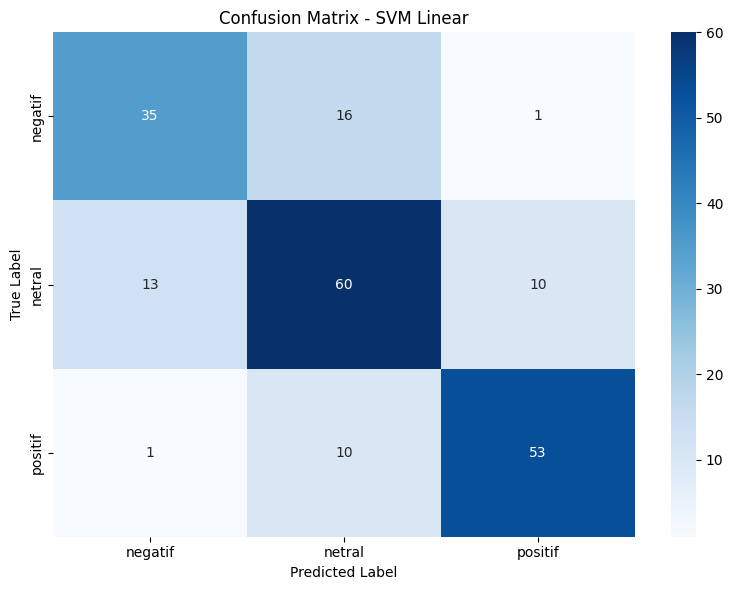


📊 METRIK PER KELAS:
 negatif: Precision=0.7143, Recall=0.6731, F1=0.6931, Support=52
  netral: Precision=0.6977, Recall=0.7229, F1=0.7101, Support=83
 positif: Precision=0.8281, Recall=0.8281, F1=0.8281, Support=64

📊 AVERAGE METRICS:
Macro Avg:    Precision=0.7467, Recall=0.7414, F1=0.7438
Weighted Avg: Precision=0.7440, Recall=0.7437, F1=0.7436

📊 DISTRIBUSI PREDIKSI (Data Testing):
Kelas      | True | Predicted
------------------------------
 negatif   |   52 |        49
  netral   |   83 |        86
 positif   |   64 |        64

📊 PARAMETER MODEL:
C (Regularization): 1.0
Max iterations: 5000
Number of iterations: 6
Number of features: 1125


In [10]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("=== MEMBANGUN MODEL KLASIFIKASI SVM LINEAR ===\n")

# Inisialisasi model SVM Linear
svm_model = LinearSVC(
    random_state=42,
    max_iter=5000,
    dual=False,
    C=1.0,
    class_weight='balanced'  # ⬅️ ini penting
)


# Training model
print("🔄 Melatih model SVM Linear...")
start_time = time.time()

svm_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training selesai dalam {training_time:.2f} detik")

# Prediksi pada data training
print("\n🔄 Melakukan prediksi pada data training...")
y_train_pred = svm_model.predict(X_train_tfidf)

# Prediksi pada data testing
print("🔄 Melakukan prediksi pada data testing...")
y_test_pred = svm_model.predict(X_test_tfidf)

print("\n" + "="*60)
print("EVALUASI MODEL")
print("="*60)

# Akurasi
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n📊 AKURASI:")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification Report
print(f"\n📊 CLASSIFICATION REPORT (Data Testing):")
print(classification_report(y_test, y_test_pred, digits=4))

# Confusion Matrix
print(f"\n📊 CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_)
plt.title('Confusion Matrix - SVM Linear')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Precision, Recall, F1-Score per kelas
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_test_pred, average=None)

print(f"\n📊 METRIK PER KELAS:")
classes = svm_model.classes_
for i, cls in enumerate(classes):
    print(f"{cls:>8}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}, Support={support[i]}")

# Macro dan Weighted Average
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')

print(f"\n📊 AVERAGE METRICS:")
print(f"Macro Avg:    Precision={macro_precision:.4f}, Recall={macro_recall:.4f}, F1={macro_f1:.4f}")
print(f"Weighted Avg: Precision={weighted_precision:.4f}, Recall={weighted_recall:.4f}, F1={weighted_f1:.4f}")

# Distribusi prediksi
print(f"\n📊 DISTRIBUSI PREDIKSI (Data Testing):")
pred_counts = pd.Series(y_test_pred).value_counts().sort_index()
true_counts = pd.Series(y_test).value_counts().sort_index()

print("Kelas      | True | Predicted")
print("-"*30)
for cls in svm_model.classes_:
    true_count = true_counts.get(cls, 0)
    pred_count = pred_counts.get(cls, 0)
    print(f"{cls:>8}   | {true_count:>4} | {pred_count:>9}")

# Model Parameters
print(f"\n📊 PARAMETER MODEL:")
print(f"C (Regularization): {svm_model.C}")
print(f"Max iterations: {svm_model.max_iter}")
print(f"Number of iterations: {svm_model.n_iter_}")
print(f"Number of features: {X_train_tfidf.shape[1]}")



In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd

print("=== PREDIKSI SENTIMEN DENGAN INDOBERT ===\n")

# Load IndoBERT sentiment model & tokenizer
print("🔄 Loading model IndoBERT...")
tokenizer =AutoTokenizer.from_pretrained("mdhugol/indonesia-bert-sentiment-classification")
model = AutoModelForSequenceClassification.from_pretrained("mdhugol/indonesia-bert-sentiment-classification")

# Pastikan device (GPU jika ada)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"✅ Model loaded pada device: {device}")

# Mapping label model IndoBERT ke label dataset
id2label = {0: "negatif", 1: "netral", 2: "positif"}

# Fungsi prediksi batch
def predict_indobert(texts, batch_size=32):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encodings = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        input_ids = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(batch_preds)
    return [id2label[i] for i in preds]

# Baca data yang sudah dipreprocessing
df_bert = pd.read_csv('preprocessing.csv')

# Hapus baris dengan cleaned comment kosong
df_bert = df_bert.dropna(subset=['Cleaned_Comment'])
df_bert = df_bert[df_bert['Cleaned_Comment'].str.strip() != '']

print(f"🔄 Melakukan prediksi pada {len(df_bert)} komentar...")

# Prediksi sentimen untuk semua data
comments_text = df_bert['Cleaned_Comment'].tolist()
predicted_sentiments = predict_indobert(comments_text)

# Tambahkan hasil prediksi ke DataFrame
df_bert['IndoBERT_Sentiment'] = predicted_sentiments

print("\n" + "="*60)
print("HASIL PREDIKSI INDOBERT")
print("="*60)

# Tampilkan distribusi hasil prediksi
print(f"\n📊 DISTRIBUSI PREDIKSI:")
sentiment_counts = pd.Series(predicted_sentiments).value_counts()
print(sentiment_counts)
print(f"\nPersentase:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / len(predicted_sentiments)) * 100
    print(f"{sentiment}: {count} ({percentage:.1f}%)")

# Tampilkan beberapa contoh hasil prediksi
print(f"\n📊 CONTOH HASIL PREDIKSI:")
sample_results = df_bert[['Comment', 'Cleaned_Comment', 'IndoBERT_Sentiment']].head(10)
print(sample_results)

# Simpan hasil ke file CSV
output_file = 'indobert_predictions.csv'
df_bert.to_csv(output_file, index=False)

print(f"\n✅ Prediksi sentimen dengan IndoBERT selesai!")
print(f"Hasil disimpan ke: {output_file}")
print(f"Total komentar yang diprediksi: {len(df_bert)}")

=== PREDIKSI SENTIMEN DENGAN INDOBERT ===

🔄 Loading model IndoBERT...
✅ Model loaded pada device: cpu
🔄 Melakukan prediksi pada 991 komentar...
✅ Model loaded pada device: cpu
🔄 Melakukan prediksi pada 991 komentar...

HASIL PREDIKSI INDOBERT

📊 DISTRIBUSI PREDIKSI:
negatif    584
netral     219
positif    188
Name: count, dtype: int64

Persentase:
negatif: 584 (58.9%)
netral: 219 (22.1%)
positif: 188 (19.0%)

📊 CONTOH HASIL PREDIKSI:
                                             Comment  \
0  Kebohongan sulit susah berbelit belit dan keju...   
1  Menutupi kebohongan\nItu sangat sulit. Harus d...   
2   Luar biasa.Pak Khozinudin..\nSehat selalu Pak...   
3  Indonesia tidak kekurangan ahli tetap kekurang...   
4  Seribu ahli tak kan mampu menutupi kebohongan....   
5  Semoga bisa adil dan tdk berat sebelah. \nJgn ...   
6  Ahmad khozinuddin mantab....\nJelas lugas g ad...   
7  Ahmad betul2 cerdas dan berani menegakkan keju...   
8  pak ahmad pengacara yg sangat cerdas, apa yg d...   


Akurasi IndoBERT pada test set: 0.4070 (40.70%)

Classification Report IndoBERT:
              precision    recall  f1-score   support

     negatif     0.3661    0.7885    0.5000        52
      netral     0.4821    0.3253    0.3885        83
     positif     0.4194    0.2031    0.2737        64

    accuracy                         0.4070       199
   macro avg     0.4225    0.4390    0.3874       199
weighted avg     0.4316    0.4070    0.3807       199



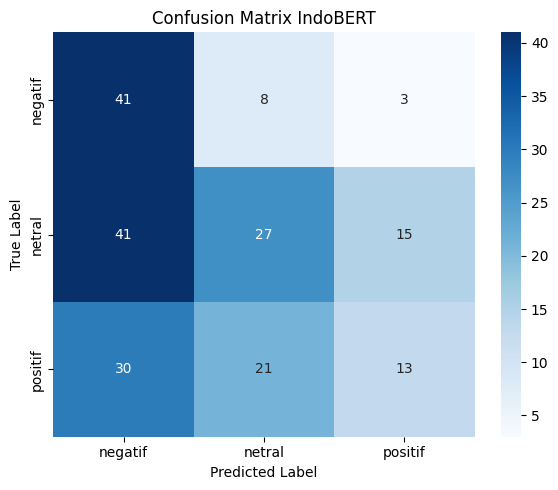


Metrik per kelas IndoBERT:
 negatif: Precision=0.3661, Recall=0.7885, F1=0.5000, Support=52
  netral: Precision=0.4821, Recall=0.3253, F1=0.3885, Support=83
 positif: Precision=0.4194, Recall=0.2031, F1=0.2737, Support=64


In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

import matplotlib.pyplot as plt

# Ambil label ground truth dan prediksi IndoBERT pada test set
y_true = test_data['Sentiment_Label'].values
y_pred_bert = results_df['Predicted_Sentiment'].values  # asumsikan results_df berisi hasil IndoBERT pada test set

# Evaluasi akurasi
accuracy_bert = accuracy_score(y_true, y_pred_bert)
print(f"Akurasi IndoBERT pada test set: {accuracy_bert:.4f} ({accuracy_bert*100:.2f}%)\n")

# Classification report
print("Classification Report IndoBERT:")
print(classification_report(y_true, y_pred_bert, digits=4))

# Confusion matrix
cm_bert = confusion_matrix(y_true, y_pred_bert, labels=['negatif', 'netral', 'positif'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['negatif', 'netral', 'positif'], 
            yticklabels=['negatif', 'netral', 'positif'])
plt.title('Confusion Matrix IndoBERT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Precision, Recall, F1 per kelas
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred_bert, labels=['negatif', 'netral', 'positif'])
print("\nMetrik per kelas IndoBERT:")
for i, label in enumerate(['negatif', 'netral', 'positif']):
    print(f"{label:>8}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}, Support={support[i]}")